# 💻 Laptop Price Intelligence & Prediction
## Exploratory Data Analysis (EDA)

Goal:
- Understand laptop pricing drivers
- Create engineered features
- Build business insights using advanced charts

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

import joypy
import squarify
OUTPUT_PATH = "../output/"

sns.set_style("whitegrid")
sns.set_context("talk")

plt.rcParams["figure.facecolor"] = "#f8f9fa"
plt.rcParams["axes.facecolor"] = "#f8f9fa"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["grid.alpha"] = 0.3

### LOAD DATASET

In [2]:
DATA_PATH = "../data/laptop_prices.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


### DATASET OVERVIEW

In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


### RENAME PRICE COLUMN

In [5]:
df.rename(columns={"Price_euros":"Price"}, inplace=True)

## MISSING VALUES CHECK

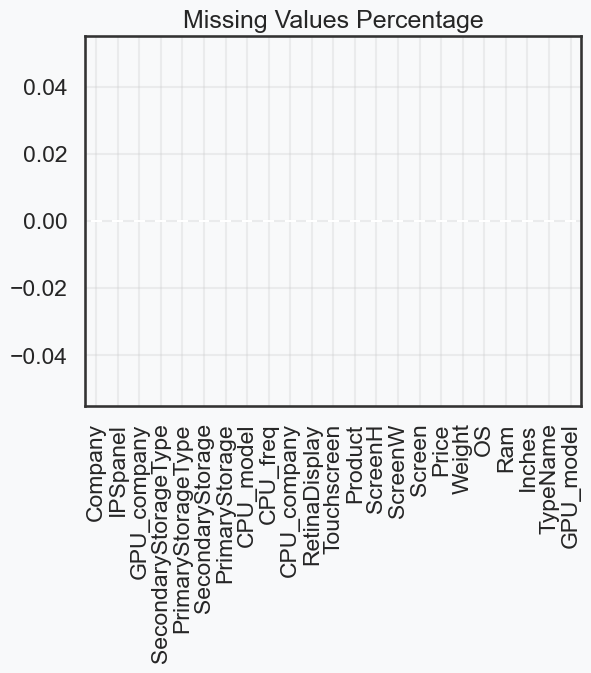

In [6]:
missing_pct = (df.isnull().mean()*100).sort_values(ascending=False)
missing_pct.plot(kind="bar", color="#6a5acd")
plt.title("Missing Values Percentage")
plt.savefig("../output/missing_value.png", dpi=300, bbox_inches="tight")
plt.show()

**Dataset contains no missing values**

### Key Drivers of Laptop Price
Based on correlation analysis

In [8]:
corr = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)
corr

Price               1.000000
Ram                 0.740287
ScreenW             0.552491
ScreenH             0.548529
CPU_freq            0.428847
SecondaryStorage    0.291207
Weight              0.211883
Inches              0.066608
PrimaryStorage     -0.124775
Name: Price, dtype: float64

### CONVERT YES/NO → BINARY

In [9]:
df["Touchscreen"] = df["Touchscreen"].map({"Yes":1,"No":0})
df["IPSpanel"] = df["IPSpanel"].map({"Yes":1,"No":0})
df["RetinaDisplay"] = df["RetinaDisplay"].map({"Yes":1,"No":0})

df[["Touchscreen","IPSpanel","RetinaDisplay"]].head()

,Touchscreen,IPSpanel,RetinaDisplay
0,0,1,1
1,0,0,0
2,0,0,0
3,0,1,1
4,0,1,1


### CREATE PPI FEATURE

In [10]:
df["ppi"] = ((df["ScreenW"]**2 + df["ScreenH"]**2)**0.5 / df["Inches"])
df[["Inches","ScreenW","ScreenH","ppi"]].head()

,Inches,ScreenW,ScreenH,ppi
0,13.3,2560,1600,226.983005
1,13.3,1440,900,127.677940
2,15.6,1920,1080,141.211998
3,15.4,2880,1800,220.534624
4,13.3,2560,1600,226.983005


## PRICE DISTRIBUTION

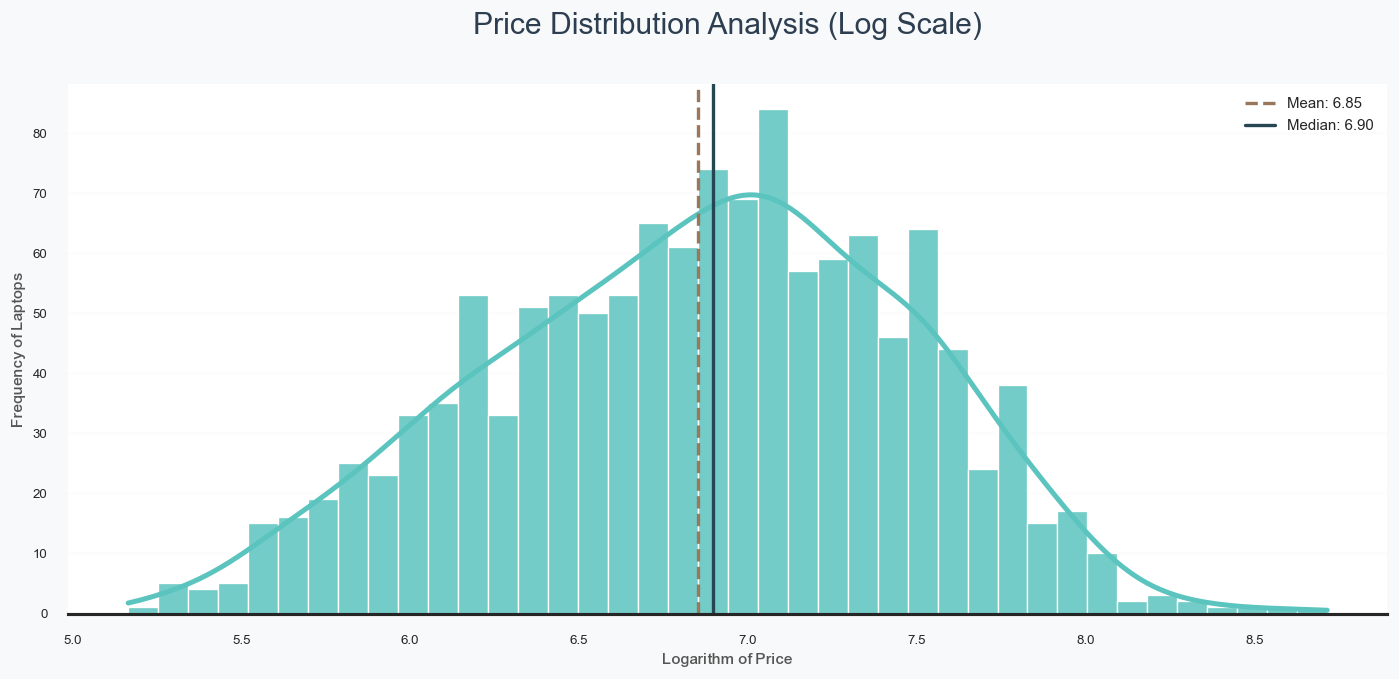

In [11]:
plt.figure(figsize=(12, 6), dpi=120)
sns.set_style("white")

df["Price_log"] = np.log1p(df["Price"]) 
log_mean = df["Price_log"].mean()
log_median = df["Price_log"].median()

main_color = "#5BC4BE"      
line_color = "#444444"      
mean_line  = "#9A765B"      

ax = sns.histplot(
    df["Price_log"],
    kde=True,
    bins=40,
    color=main_color,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85,
    line_kws={"color": line_color, "linewidth": 3})

plt.axvline(log_mean, color=mean_line, linestyle='--', linewidth=2, label=f'Mean: {log_mean:.2f}')
plt.axvline(log_median, color='#264653', linestyle='-', linewidth=2, label=f'Median: {log_median:.2f}')
plt.title("Price Distribution Analysis (Log Scale)", fontsize=18, fontweight='light', pad=30, color='#2c3e50')
plt.xlabel("Logarithm of Price", fontsize=10, fontweight='500', color='#555555')
plt.ylabel("Frequency of Laptops", fontsize=10, fontweight='500', color='#555555')
plt.legend(frameon=False, loc='upper right', fontsize=9)
sns.despine(left=True, bottom=False)
plt.grid(axis='y', linestyle='-', alpha=0.05) 
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.savefig("../output/price_distribution_analysis.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Outlier Detection in Laptop Prices

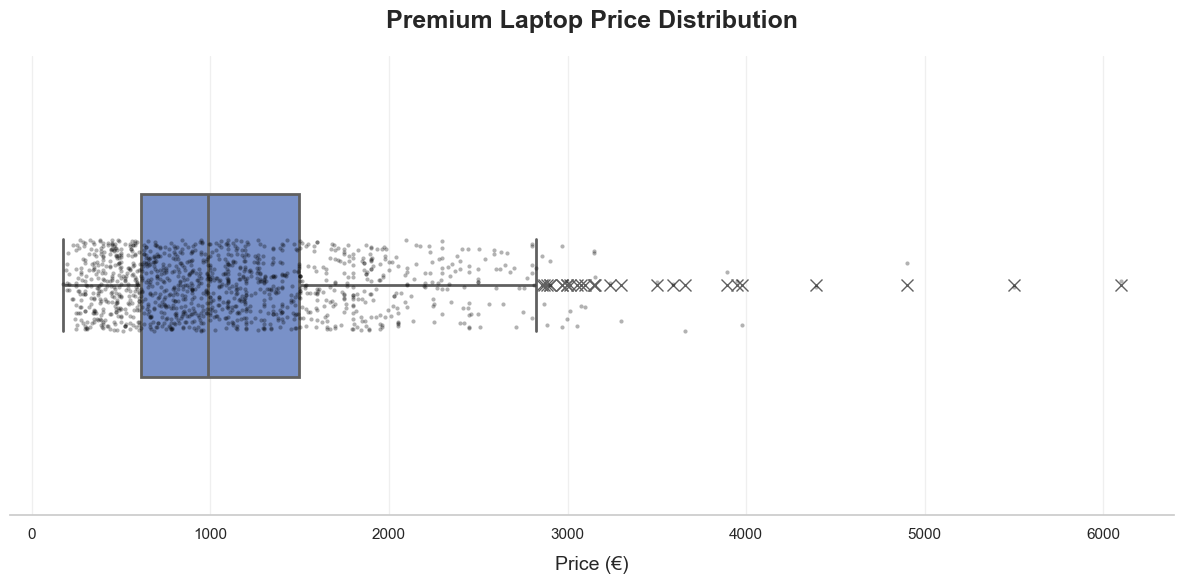

In [12]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.stripplot(x=df["Price"], color="black", alpha=0.3, size=3, jitter=True)
sns.boxplot(
    x=df["Price"], 
    color="#6C8CD5", 
    width=0.4, 
    linewidth=2,
    flierprops={"marker": "x", "markerfacecolor": "red", "markersize": 8})

plt.title("Premium Laptop Price Distribution", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Price (€)", fontsize=14, labelpad=10)
sns.despine(left=True)
plt.savefig("../output/price_distribution_detection.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## Brand vs Price

<Figure size 1000x600 with 0 Axes>

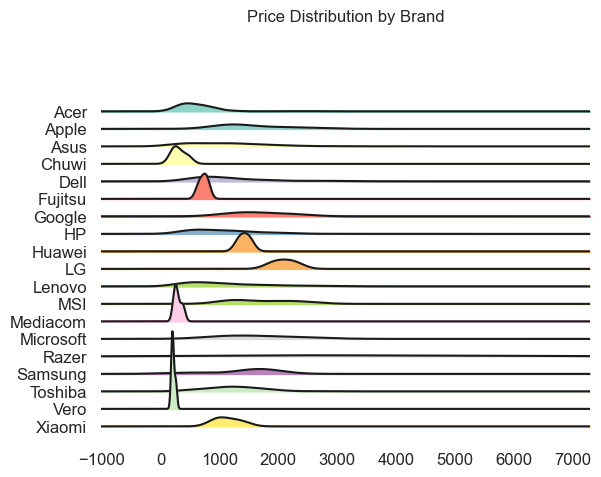

In [19]:
plt.figure(figsize=(10,6))
joypy.joyplot(df, by="Company", column="Price",
              colormap=plt.cm.Set3)
plt.title("Price Distribution by Brand")
plt.savefig("../output/Brand_vs_Price.png", dpi=300, bbox_inches="tight")
plt.show()

## RAM vs Price

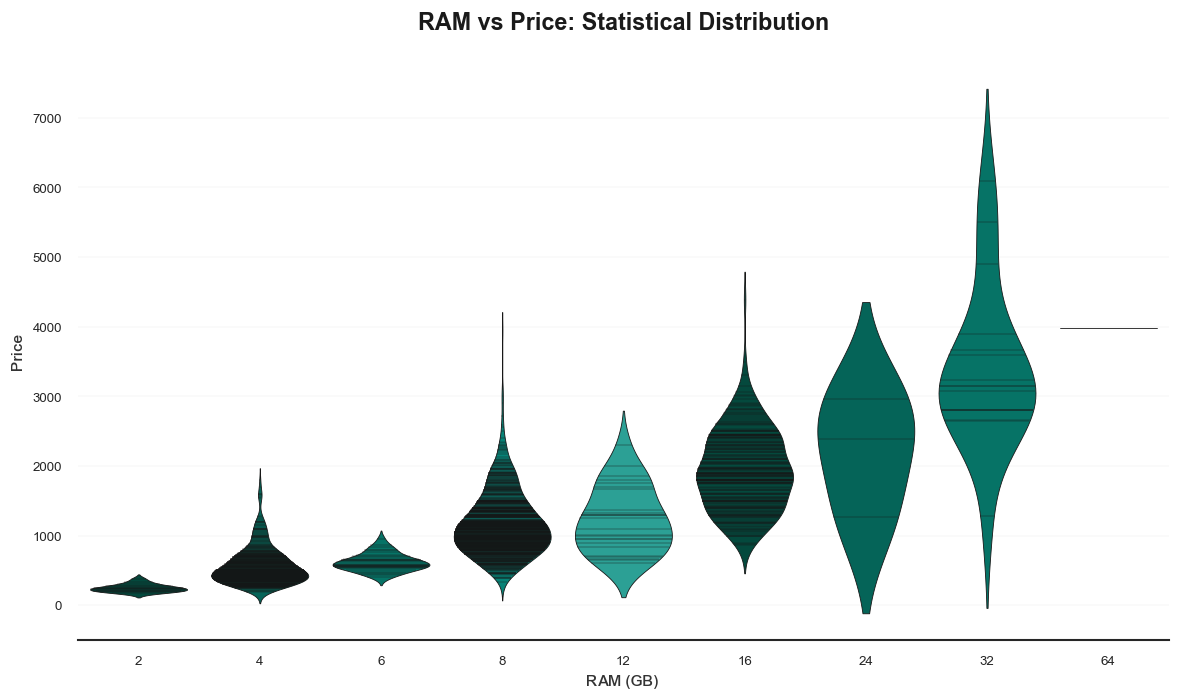

In [14]:
plt.figure(figsize=(10, 6), dpi=120)
sns.set_style("white")
unique_palette = ["#004d40", "#00695c", "#00796b", "#00897b", "#26a69a"]
ax = sns.violinplot(x="Ram", y="Price", data=df, 
                    palette=unique_palette, 
                    linewidth=0.5, 
                    inner="stick", 
                    saturation=0.9)

plt.title("RAM vs Price: Statistical Distribution", fontsize=14, fontweight='bold', pad=20, color='#1a1a1a')
plt.xlabel("RAM (GB)", fontsize=10, fontweight='500', color='#333333')
plt.ylabel("Price", fontsize=10, fontweight='500', color='#333333')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
sns.despine(left=True)
plt.grid(axis='y', linestyle='-', alpha=0.1) 
plt.savefig("../output/RAM_vs_Price.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Statistical Insights

Key statistical summary of important variables affecting laptop price.

In [15]:
df[["Price","Ram","Weight","ppi","CPU_freq"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,1275.0,1134.969059,700.752504,174.000000,609.000000,989.000000,1496.500000,6099.000000
Ram,1275.0,8.440784,5.097809,2.000000,4.000000,8.000000,8.000000,64.000000
Weight,1275.0,2.040525,0.669196,0.690000,1.500000,2.040000,2.310000,4.700000
ppi,1275.0,146.983017,42.982887,90.583402,127.335675,141.211998,157.350512,352.465147
CPU_freq,1275.0,2.302980,0.503846,0.900000,2.000000,2.500000,2.700000,3.600000


## Business & Statistical Analysis
Understanding real laptop price drivers

### Correlation Analysis
Relationship between numerical features and laptop price

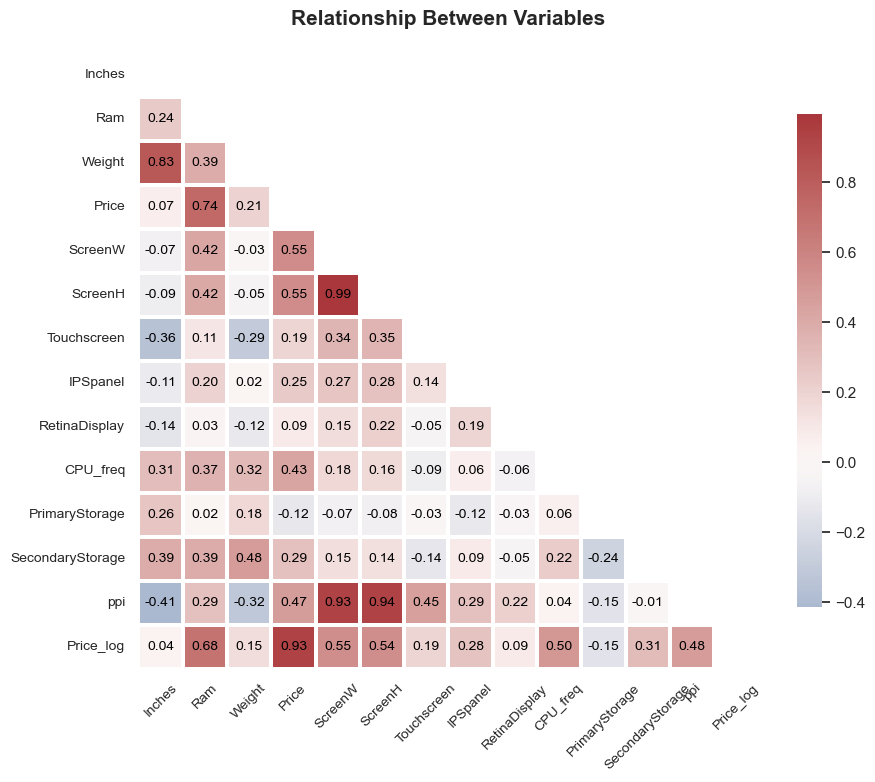

In [17]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool)) 

plt.figure(figsize=(10, 8), dpi=100)

sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap="vlag",         
            center=0,           
            linewidths=1.5,      
            cbar_kws={"shrink": .8},
            annot_kws={"size": 10, "weight": "normal", "color": "black"})

plt.title("Relationship Between Variables", fontsize=15, fontweight='bold', pad=20)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.savefig("../output/correlation_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## OS vs PRICE

### Operating System vs Price
Do MacBooks cost more than Windows laptops?

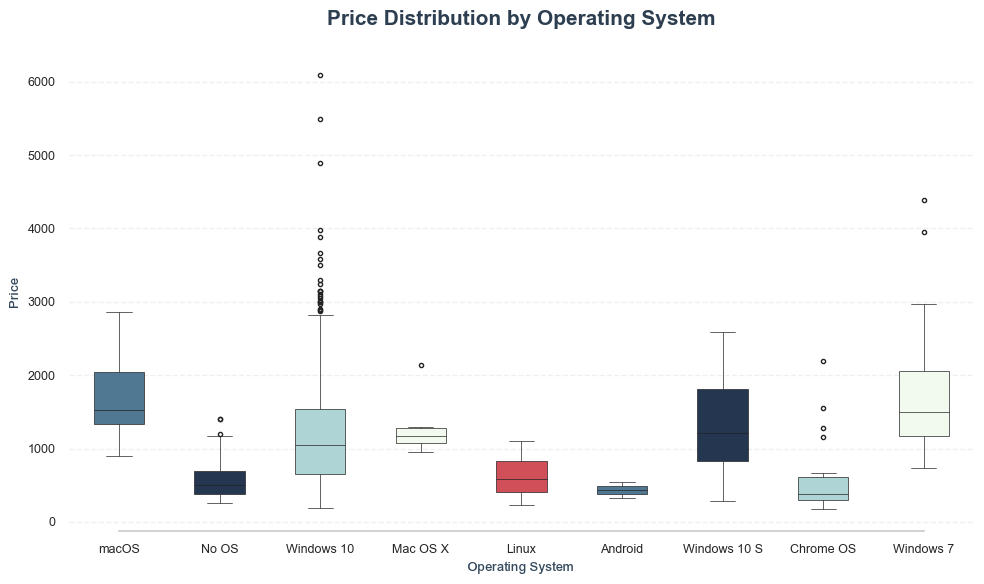

In [21]:
plt.figure(figsize=(10, 6), dpi=100)
sns.set_style("whitegrid", {'axes.grid': False}) 

prof_palette = ["#457B9D", "#1D3557", "#A8DADC", "#F1FAEE", "#E63946"]
sns.boxplot(data=df, x="OS", y="Price", 
            palette=prof_palette, 
            width=0.5,           
            linewidth=0.5,    
            fliersize=3, 
            whis=1.5)          

plt.title("Price Distribution by Operating System", fontsize=15, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel("Operating System", fontsize=10, fontweight='500', color='#34495e')
plt.ylabel("Price", fontsize=10, fontweight='500', color='#34495e')
plt.xticks(rotation=0, fontsize=9) 
plt.yticks(fontsize=9)
sns.despine(trim=True, left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig("../output/OS_vs_price.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## LAPTOP TYPE vs PRICE

### Laptop Type vs Price
Gaming vs Ultrabook vs Notebook price comparison

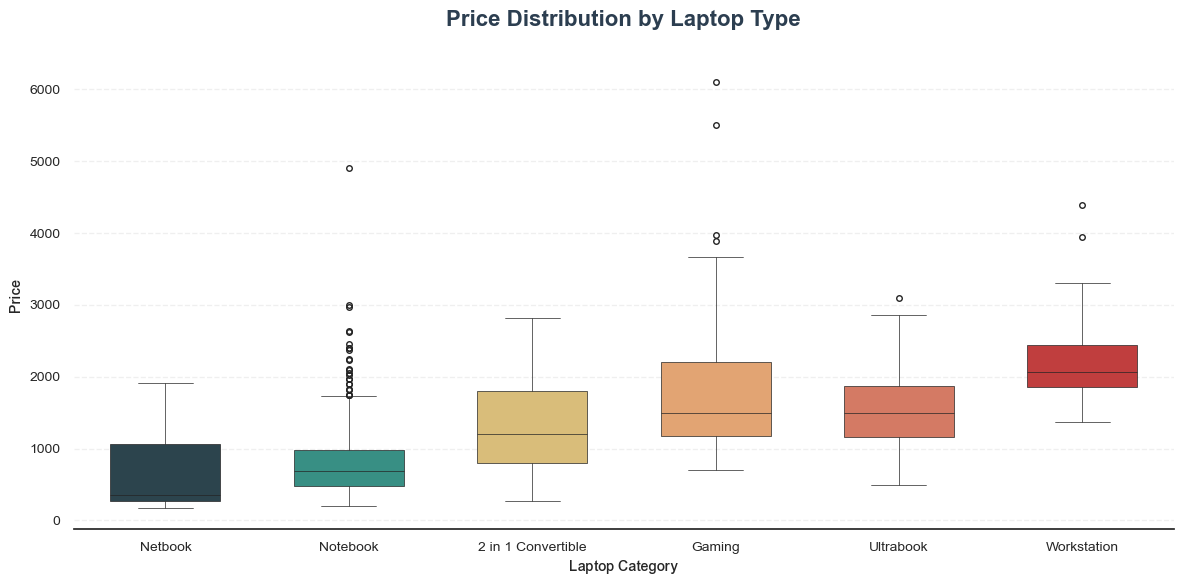

In [23]:
order = df.groupby("TypeName")["Price"].median().sort_values().index
plt.figure(figsize=(12, 6), dpi=100)
sns.set_style("white")

midnight_palette = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#D62828"]
sns.boxplot(data=df, x="TypeName", y="Price", 
            order=order,           
            palette=midnight_palette, 
            width=0.6,            
            linewidth=0.5,         
            fliersize=4,          
            whis=1.5)

plt.title("Price Distribution by Laptop Type", fontsize=16, fontweight='bold', pad=25, color='#2c3e50')
plt.xlabel("Laptop Category", fontsize=11, fontweight='500')
plt.ylabel("Price", fontsize=11, fontweight='500')
plt.xticks(fontsize=10) 
plt.yticks(fontsize=10)
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3) 
plt.savefig("../output/Laptop_vs_Price.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## WEIGHT vs PRICE

### Weight vs Price Relationship
Are lighter laptops more expensive?

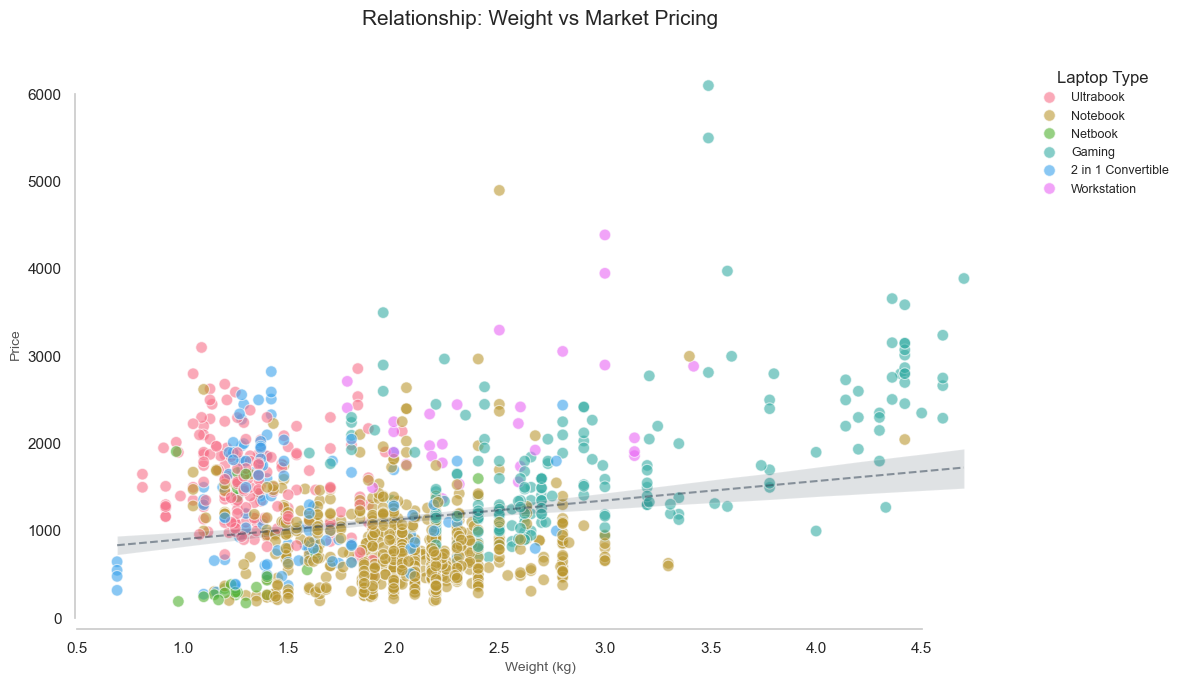

In [24]:
plt.figure(figsize=(12, 7), dpi=100)
sns.set_style("whitegrid", {'axes.grid': False})
palette = sns.color_palette("husl", len(df["TypeName"].unique()))
sns.scatterplot(data=df, x="Weight", y="Price", 
                hue="TypeName", 
                palette=palette,
                s=70, 
                alpha=0.6, 
                edgecolor='white', 
                linewidth=0.8)
sns.regplot(data=df, x="Weight", y="Price", scatter=False, color="#2c3e50", 
            line_kws={"linewidth": 1.5, "alpha": 0.5, "linestyle": "--"})
plt.title("Relationship: Weight vs Market Pricing", fontsize=15, fontweight='300', pad=25)
plt.xlabel("Weight (kg)", fontsize=10, color="#555555")
plt.ylabel("Price", fontsize=10, color="#555555")
plt.legend(title="Laptop Type", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)

sns.despine(trim=True)
plt.savefig("../output/weight_vs_price.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## STORAGE TYPE vs PRICE

### Storage Type vs Price
SSD vs HDD pricing impact

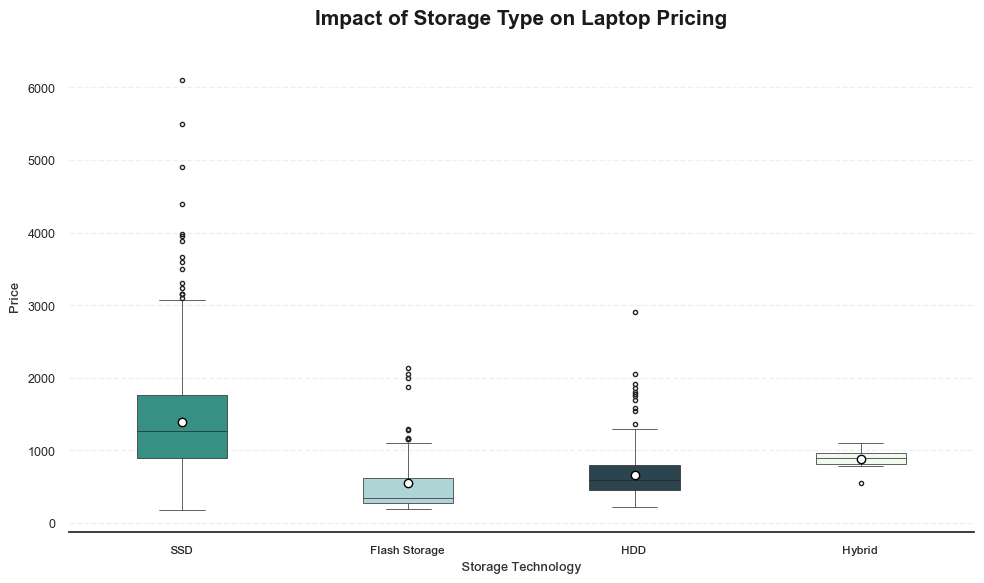

In [25]:
plt.figure(figsize=(10, 6), dpi=100)
sns.set_style("white")
storage_palette = ["#2A9D8F", "#A8DADC", "#264653", "#F1FAEE"]
sns.boxplot(data=df, x="PrimaryStorageType", y="Price", 
            palette=storage_palette, 
            width=0.4,           
            linewidth=0.5, 
            fliersize=3,         
            showmeans=True,     
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"})

plt.title("Impact of Storage Type on Laptop Pricing", fontsize=15, fontweight='bold', pad=25, color='#1a1a1a')
plt.xlabel("Storage Technology", fontsize=10, fontweight='500', color='#333333')
plt.ylabel("Price", fontsize=10, fontweight='500', color='#333333')

plt.xticks(fontsize=9, fontweight='500')
plt.yticks(fontsize=9)
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig("../output/storage_vs_Price.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## CPU vs Price

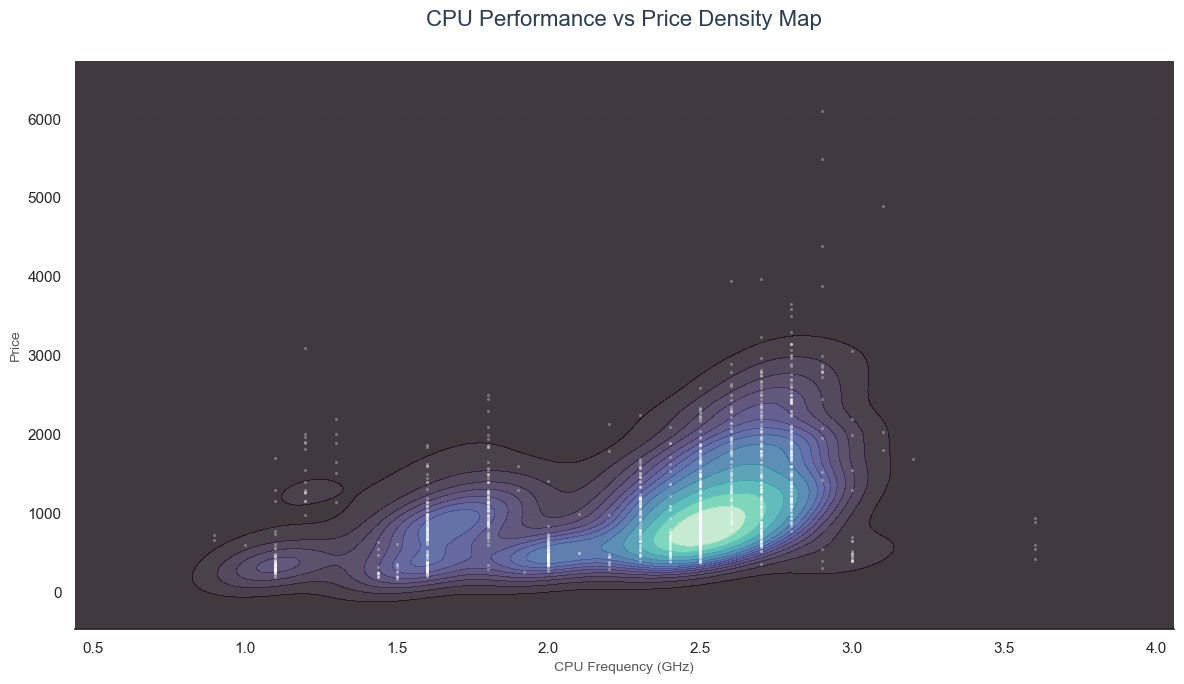

In [26]:
plt.figure(figsize=(12, 7), dpi=100)
sns.set_style("white")
sns.kdeplot(
    data=df, x="CPU_freq", y="Price",
    fill=True,           
    thresh=0,            
    levels=15,           
    cmap="mako",         
    alpha=0.8)
sns.scatterplot( data=df, x="CPU_freq", y="Price",
    s=5, color="white", alpha=0.3, linewidth=0)
plt.title("CPU Performance vs Price Density Map", fontsize=16, fontweight='300', pad=25, color='#2c3e50')
plt.xlabel("CPU Frequency (GHz)", fontsize=10, color='#555555')
plt.ylabel("Price", fontsize=10, color='#555555')
sns.despine(left=True, bottom=False)
plt.grid(axis='y', linestyle='--', alpha=0.1) 
plt.savefig("../output/CPU_vs_Price.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## Market Structure

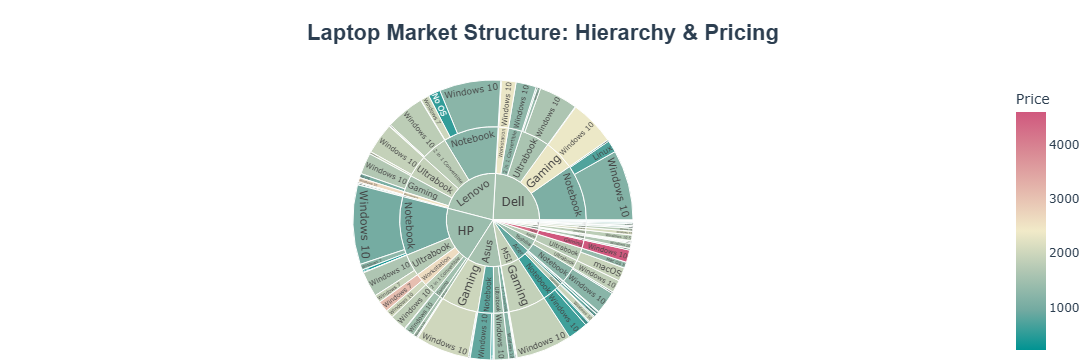

<Figure size 640x480 with 0 Axes>

In [27]:
fig = px.sunburst(
    df, 
    path=["Company", "TypeName", "OS"], 
    values="Price",
    color="Price",                 
    color_continuous_scale='Tealrose', 
    title="<b>Laptop Market Structure: Hierarchy & Pricing</b>",
    template="plotly_white")
fig.update_layout(
    title_font_size=22,
    title_font_family="Arial",
    title_x=0.5,                   
    margin=dict(t=80, l=0, r=0, b=0), 
    font=dict(family="Verdana", size=12, color="#2c3e50"))

fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Total Value: $%{value:,.2f}<br>Share: %{percentParent:.1%}')
plt.savefig("../output/Market_structure.png", dpi=300, bbox_inches="tight")
fig.show()

## Save Cleaned Dataset

Saving the processed dataset for Machine Learning modeling.

In [28]:
df.to_csv("../data/laptop_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
